# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [ ]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.sparse import csr_matrix, coo_matrix
import polars as pl
import gc

DATA_DIR = 'data'
MODELS_DIR = 'models'

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [ ]:
tracks = pd.read_parquet(f"{DATA_DIR}/tracks.parquet")
tracks.head()

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


In [ ]:
catalog_names = pd.read_parquet(f'{DATA_DIR}/catalog_names.parquet')
catalog_names.head()

,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack


In [ ]:
import polars as pl

int_pl = pl.scan_parquet(f'{DATA_DIR}/interactions.parquet')
interactions = int_pl.collect().drop('__index_level_0__').to_pandas()

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [5]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB


In [ ]:
print(tracks['albums'].isna().sum())
print(tracks['artists'].isna().sum())
print(tracks['genres'].isna().sum())

0
0
0


In [ ]:
print(f"Количество треков без альбомов: {(tracks['albums'].str.len() == 0).sum()}")
print(f"Количество треков без артистов: {(tracks['artists'].str.len() == 0).sum()}")
print(f"Количество треков без жанров: {(tracks['genres'].str.len() == 0).sum()}")

Количество треков без альбомов: 18
Количество треков без артистов: 15369
Количество треков без жанров: 3687


Отфильтруем треки, у которых нет жанров, потому что в построенной матрице они все равно будут иметь пустые строки

In [6]:
tracks = tracks[tracks['genres'].str.len() > 0]

In [ ]:
tracks['track_id'] = tracks['track_id'].astype('int32')

In [ ]:
catalog_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB


In [ ]:
catalog_names['type'].unique()

array(['album', 'artist', 'genre', 'track'], dtype=object)

In [ ]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 5.4 GB


In [ ]:
interactions['track_seq'].isna().any()

False

In [3]:
print(f"Количество уникальных пользователей: {interactions['user_id'].nunique()}")

Количество уникальных пользователей: 1373221


In [7]:
def optimize_numeric_types(df: pd.DataFrame) -> pd.DataFrame:
    for col in df.select_dtypes(include=['int', 'float']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer' if 'int' in str(df[col].dtype) else 'float')

    return df

In [8]:
tracks = optimize_numeric_types(tracks)
interactions = optimize_numeric_types(interactions)

In [9]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
Index: 996313 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   track_id  996313 non-null  int32 
 1   albums    996313 non-null  object
 2   artists   996313 non-null  object
 3   genres    996313 non-null  object
dtypes: int32(1), object(3)
memory usage: 34.2+ MB


In [12]:
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222629898 entries, 0 to 222629897
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), int32(2)
memory usage: 3.7 GB


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

В исходном наборе данных имеются пропуски среди альбомов, артистов и жанров. Было принято решение отбросить все треки, у которых не заполено поле с жанрами, поскольку именно этот признак будет использоваться для построения матрицы взаимодействий. Остальные признаки не должны сильно повлиять на качество рекомендаций

# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

<Axes: xlabel='track_id', ylabel='Count'>

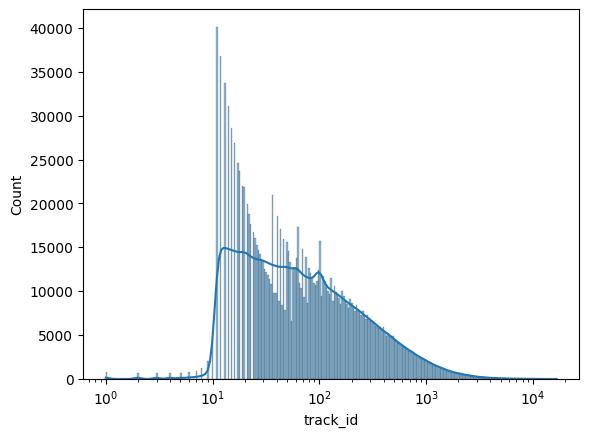

In [13]:
listened_cnt = interactions.groupby('user_id')['track_id'].count().reset_index()

sns.histplot(
    listened_cnt['track_id'], 
    log_scale=True,
    kde=True)

Наиболее популярные треки

In [14]:
track_listenings = interactions['track_id'].value_counts().reset_index()
track_listenings.columns= ['track_id', 'listenings']
most_popular = track_listenings.sort_values(by='listenings', ascending=False).head(10)
most_popular = most_popular.merge(catalog_names[catalog_names['type'] == 'track'][['id', 'name']], left_on='track_id', right_on='id', how='left').drop(columns=['id'])

most_popular

,track_id,listenings,name
0,53404,111062,Smells Like Teen Spirit
1,33311009,106921,Believer
2,178529,101924,Numb
3,35505245,99490,I Got Love
4,65851540,86670,Юность
5,24692821,86246,Way Down We Go
6,32947997,85886,Shape of You
7,51241318,85244,In The End
8,795836,85042,Shape Of My Heart
9,45499814,84748,Life


Наиболее популярные жанры

In [15]:
most_popular_genres = track_listenings.merge(tracks[['track_id', 'genres']], on='track_id', how='left')\
    .explode(column=['genres'], ignore_index=True)\
    .groupby('genres')['listenings'].sum().reset_index()\
    .sort_values(by='listenings', ascending=False)\
    .merge(catalog_names[catalog_names['type'] == 'genre'][['id', 'name']], left_on='genres', right_on='id', how='left')\
    .drop(columns=['genres']).head(10)

most_popular_genres

,listenings,id,name
0,55578312,11.0,pop
1,37799821,75.0,rap
2,31092013,102.0,allrock
3,26626241,20.0,ruspop
4,25303695,3.0,rusrap
5,20120981,68.0,electronics
6,16291557,16.0,dance
7,13166147,2.0,rusrock
8,12772644,14.0,rock
9,12437375,47.0,metal


Треки, которые никто не прослушал

In [ ]:
track_listenings.query("listenings == 0")

,track_id,listenings


In [ ]:
track_listenings.sort_values(by='listenings', ascending=False).tail()

,track_id,listenings
999847,592600,5
999848,61201731,5
999849,52080116,5
999850,73942221,5
999851,692654,5


In [ ]:
track_ids = tracks['track_id'].unique().tolist()

interactions[~interactions['track_id'].isin(track_ids)]['track_id'].count()

# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [16]:
items = tracks.copy()
events = interactions.copy()

In [17]:
items = items.rename(columns={'track_id': 'item_id'})
events = events.rename(columns={'track_id': 'item_id'})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [ ]:
items.to_parquet(f"{DATA_DIR}/items.parquet", index=False)
events.to_parquet(f"{DATA_DIR}/events.parquet", index=False)

In [27]:
import boto3
import os
from dotenv import load_dotenv

load_dotenv()

s3 = boto3.client('s3', endpoint_url=os.environ['S3_ENDPOINT_URL'])

s3.upload_file('items.parquet', os.environ['S3_BUCKET_NAME'], 'recsys/data/items.parquet')
s3.upload_file('events.parquet', os.environ['S3_BUCKET_NAME'], 'recsys/data/events.parquet')

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [28]:
import gc

del tracks
del interactions
del track_listenings
del most_popular
del most_popular_genres
del listened_cnt

gc.collect()

4861

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [ ]:
items = pd.read_parquet(f'{DATA_DIR}/items.parquet')

In [ ]:
import polars as pl

events_pl = pl.scan_parquet(f'{DATA_DIR}/events.parquet')

events = events_pl.collect().to_pandas()

In [4]:
events.head()

,user_id,item_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [6]:
item_ids = items['item_id'].unique().tolist()

events_clean = events[events['item_id'].isin(item_ids)]

In [7]:
global_time_split_date = pd.to_datetime('2022-12-17')

global_time_split_idx = events_clean['started_at'] < global_time_split_date
events_train = events_clean[global_time_split_idx]
events_test = events_clean[~global_time_split_idx]

In [8]:
del item_ids
del global_time_split_idx
gc.collect()

31

# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [ ]:
top_popular = events['item_id'].value_counts().reset_index()
top_popular.columns = ['item_id', 'listenings']

top_popular = top_popular.sort_values(by='listenings', ascending=False).head(100)

top_popular.to_parquet(f'{DATA_DIR}/top_popular.parquet')

In [ ]:
top_popular.head()

,item_id,listenings
0,53404,111062
1,33311009,106921
2,178529,101924
3,35505245,99490
4,65851540,86670


# Персональные

Рассчитаем персональные рекомендации.

In [7]:
import sklearn.preprocessing

user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events["user_id"])
events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])

item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_train["item_id_enc"] = item_encoder.transform(events_train['item_id'])
events_test["item_id_enc"] = item_encoder.transform(events_test['item_id'])

/tmp/ipykernel_66971/1713451691.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_train["user_id_enc"] = user_encoder.transform(events_train["user_id"])
/tmp/ipykernel_66971/1713451691.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_test["user_id_enc"] = user_encoder.transform(events_test["user_id"])
/tmp/ipykernel_66971/1713451691.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [8]:
del events
gc.collect()

0

In [ ]:
import joblib

joblib.dump(user_encoder, f'{MODELS_DIR}/user_encoder.pkl')
joblib.dump(item_encoder, f'{MODELS_DIR}/item_encoder.pkl')

In [ ]:
import joblib

with open(f'{MODELS_DIR}/user_encoder.pkl', 'rb') as f:
    user_encoder = joblib.load(f)

with open(f'{MODELS_DIR}/item_encoder.pkl', 'rb') as f:
    item_encoder = joblib.load(f)

In [ ]:
events_train['item_id_enc'].max()

996312

In [7]:
len(events_train)

209676873

Ограничиваю тестовую выборку до 100 последних действий для оптимизации использования памяти

In [10]:
min_interactions = 5
max_events_per_user = 100

user_counts = events_train['user_id'].value_counts()
active_users = user_counts[user_counts >= min_interactions].index
del user_counts
gc.collect()

events_train = events_train[events_train['user_id'].isin(active_users)]
del active_users
gc.collect()

print(f"Размер с минимальным количеством взаимодействий {min_interactions}: {len(events_train)}")

events_train.sort_values(by='started_at', ascending=False, inplace=True)
rank = events_train.groupby('user_id').cumcount()

events_train = events_train[rank < max_events_per_user].reset_index(drop=True)
del rank
gc.collect()

print(f"Размер с последними {max_events_per_user} взаимодействиями: {len(events_train)}")
events_train.info(memory_usage='deep')

Размер с минимальным количеством взаимодействий 5: 209651341
Размер с последними 100 взаимодействиями: 76798567
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76798567 entries, 0 to 76798566
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   user_id      int32         
 1   item_id      int32         
 2   track_seq    int16         
 3   started_at   datetime64[ns]
 4   user_id_enc  int64         
 5   item_id_enc  int64         
dtypes: datetime64[ns](1), int16(1), int32(2), int64(2)
memory usage: 2.4 GB


In [ ]:
events_train.to_parquet(f'{DATA_DIR}/events_train.parquet')

In [ ]:
events_test.to_parquet(f'{DATA_DIR}/events_test.parquet')

In [ ]:
events_train = pd.read_parquet(f'{DATA_DIR}/events_train.parquet')

In [ ]:
u = events_train['user_id_enc'].values
i = events_train['item_id_enc'].values

data = np.ones(len(events_train), dtype='int32')

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

matrix = coo_matrix((data, (u, i)), shape=(num_users, num_items))

matrix = matrix.astype(np.float32)

user_item_matrix_train = matrix.tocsr()

del data
del u
del i
del matrix
gc.collect()

65

In [ ]:
joblib.dump(user_item_matrix_train, f'{MODELS_DIR}/user_item_matrix_train.pkl')

['user_item_matrix_train.pkl']

In [ ]:
with open(f'{MODELS_DIR}/user_item_matrix_train.pkl', 'rb') as f:
    user_item_matrix_train = joblib.load(f)

In [ ]:
import gc

del events_clean
del events_train
del events_test

gc.collect()

0

In [11]:
def get_sparse_matrix_mem(matrix):
    mem = matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes
    print(f"Вес CSR матрицы: {mem / 1024**2:.2f} MB")
    print(f"Вес CSR матрицы: {mem / 1024**3:.2f} GB")
    
get_sparse_matrix_mem(user_item_matrix_train)

Вес CSR матрицы: 591.16 MB
Вес CSR матрицы: 0.58 GB


In [4]:
from implicit.als import AlternatingLeastSquares

als_collab_model = AlternatingLeastSquares(factors=32, iterations=10, regularization=0.05)
als_collab_model.fit(user_item_matrix_train)

/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()
100%|██████████| 10/10 [01:55<00:00, 11.53s/it]


In [ ]:
als_collab_model.save(f'{MODELS_DIR}/als_model.npz')

In [ ]:
import numpy as np

np.save(f'{MODELS_DIR}/user_factors.npy', als_collab_model.user_factors)
np.save(f'{MODELS_DIR}/item_factors.npy', als_collab_model.item_factors)

In [7]:
import psutil
import os

process = psutil.Process(os.getpid())
print(f"Общее потребление процессом: {process.memory_info().rss / 1024**3:.2f} GB")

Общее потребление процессом: 1.08 GB


In [9]:
def get_model_memory_usage(model):
    user_factors = model.user_factors
    item_factors = model.item_factors
    
    user_mem = user_factors.nbytes
    item_mem = item_factors.nbytes
    total_mem = user_mem + item_mem
    
    print(f"User Factors: {user_mem / 1024**2:.2f} MB")
    print(f"Item Factors: {item_mem / 1024**2:.2f} MB")
    print(f"---")
    print(f"Общий вес модели в RAM: {total_mem / 1024**2:.2f} MB ({total_mem / 1024**3:.2f} GB)")

get_model_memory_usage(als_collab_model)

User Factors: 167.63 MB
Item Factors: 121.62 MB
---
Общий вес модели в RAM: 289.25 MB (0.28 GB)


In [ ]:
import numpy as np
from implicit.als import AlternatingLeastSquares

data = np.load(f'{MODELS_DIR}/als_model.npz', allow_pickle=True)

factors = data['user_factors'].shape[1]
als_collab_model = AlternatingLeastSquares(factors=factors)

als_collab_model.user_factors = data['user_factors']
als_collab_model.item_factors = data['item_factors']

del data
del factors

/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 4 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


In [32]:
import pyarrow as pa
import pyarrow.parquet as pq
from tqdm.auto import tqdm

def recommend_with_batches(model, save_filename, user_item_matrix, user_encoder, item_encoder, schema=None, batch_size=5000, N_rec=30, filter_already_liked_items=True):
    user_ids_encoded = np.arange(len(user_encoder.classes_))

    n_batches = int(np.ceil(len(user_ids_encoded) / batch_size))

    print(f"Total batches: {n_batches}")

    if schema is None:
        schema = pa.schema([
            ('user_id', pa.int32()),
            ('item_id', pa.int32()),
            ('score', pa.float32())
        ])

    writer = pq.ParquetWriter(save_filename, schema=schema)

    try:
        for i in tqdm(range(n_batches)):
            print(f"Procesing batch {i}/{n_batches}")
            start = i * batch_size
            end = min(len(user_ids_encoded), (i+1)*batch_size)
            batch_items = user_ids_encoded[start:end]

            ids, scores = model.recommend(
                batch_items,
                user_item_matrix[batch_items],
                filter_already_liked_items=filter_already_liked_items,
                N=N_rec
            )

            real_user_ids = user_encoder.inverse_transform(batch_items)
            user_column = np.repeat(real_user_ids, N_rec)

            ids_flat = ids.reshape(-1)
            scores_flat = scores.reshape(-1)

            valid_mask = ids_flat != -1

            valid_users = user_column[valid_mask]
            valid_items = item_encoder.inverse_transform(ids_flat[valid_mask])
            valid_scores = scores_flat[valid_mask]

            batch_df = pd.DataFrame({
                'user_id': valid_users,
                'item_id': valid_items,
                'score': valid_scores
            })

            table = pa.Table.from_pandas(batch_df, schema=schema)
            writer.write_table(table)

            del batch_df, batch_items, ids, scores, real_user_ids, user_column,
            ids_flat, scores_flat, valid_users, valid_items, valid_scores
            gc.collect()

    except Exception as e:
        print(f"Error: {e}")
        writer.close()
        raise

    finally:
        writer.close()

In [ ]:
recommend_with_batches(
    model=als_collab_model,
    save_filename=f'{DATA_DIR}/personal_als.parquet', 
    user_item_matrix=user_item_matrix_train, 
    user_encoder=user_encoder, 
    item_encoder=item_encoder,
    batch_size=10000
)

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np
from tqdm.auto import tqdm

filename = f'{DATA_DIR}/similar_items.parquet'
item_ids_enc = np.arange(len(item_encoder.classes_))
batch_size = 1000
N_sim = 20

n_batches = int(np.ceil(len(item_ids_enc)/batch_size))

schema = pa.schema([
    ('item_id', pa.int32()),
    ('similar_item_id', pa.int32()),
    ('score', pa.float32())
])

writer = pq.ParquetWriter(filename, schema, compression='snappy')

try:
    for i in tqdm(range(n_batches)):
        print(f"Batch {i+1}/{n_batches}")

        start = i * batch_size
        end = min((i+1)*batch_size, len(item_ids_enc))
        batch_items = item_ids_enc[start:end]
        
        ids, scores = als_collab_model.similar_items(
            batch_items,
            N=N_sim
        )

        real_item_ids = item_encoder.inverse_transform(batch_items)
        item_column = np.repeat(real_item_ids, N_sim)

        sim_item_column = item_encoder.inverse_transform(ids.reshape(-1))
        score_column = scores.reshape(-1)

        batch_df = pd.DataFrame({
            'item_id': item_column,
            'similar_item_id': sim_item_column,
            'score': score_column
        })

        table = pa.Table.from_pandas(batch_df, schema=schema)
        writer.write_table(table)

finally:
    writer.close()

  0%|          | 0/997 [00:00<?, ?it/s]

Batch 1/997


  0%|          | 1/997 [00:02<47:57,  2.89s/it]

Batch 2/997


  0%|          | 2/997 [00:05<48:07,  2.90s/it]

...

100%|█████████▉| 995/997 [46:44<00:05,  2.82s/it]

Batch 996/997


100%|█████████▉| 996/997 [46:47<00:02,  2.77s/it]

Batch 997/997


100%|██████████| 997/997 [46:48<00:00,  2.82s/it]


In [ ]:
similar_items = pd.read_parquet(f'{DATA_DIR}/similar_items.parquet')

In [10]:
len(similar_items)

19926260

In [ ]:
items = pd.read_parquet(f'{DATA_DIR}/items.parquet')

In [4]:
def get_item_genre_matrix(items, genres, item_encoder, genres_encoder):
    items['item_id_enc'] = item_encoder.transform(items['item_id'])
    exploded_items = items.explode('genres')

    exploded_items['genre_id_enc'] = genres_encoder.transform(exploded_items['genres'])

    item_indeces = exploded_items['item_id_enc'].values
    genre_indeces = exploded_items['genre_id_enc'].values

    num_rows = len(items)
    num_cols = len(genres)

    data = np.ones(len(exploded_items), dtype='int32')

    item_genre_matrix = csr_matrix((data, (item_indeces, genre_indeces)), shape=(num_rows, num_cols))

    del exploded_items, item_indeces, genre_indeces, data
    gc.collect()

    return item_genre_matrix

In [ ]:
catalog_names = pd.read_parquet(f'{DATA_DIR}/catalog_names.parquet')

In [8]:
genres = items.explode('genres')['genres'].unique()

In [ ]:
from sklearn.preprocessing import LabelEncoder

genres_encoder = LabelEncoder()
genres_encoded = genres_encoder.fit_transform(genres)

joblib.dump(genres_encoder, f'{MODELS_DIR}/genres_encoder.pkl')

['genres_encoder.pkl']

In [10]:
item_genre_matrix = get_item_genre_matrix(items, genres_encoded, item_encoder, genres_encoder)

In [ ]:
from implicit.nearest_neighbours import BM25Recommender

genre_item_matrix = item_genre_matrix.T.tocsr()

content_model = BM25Recommender(K=100)
content_model.fit(genre_item_matrix)

/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mle-user/mle_projects/mle-music-recsys/env_recsys_start/lib/python3.10/site-packages/implicit/utils.py:164: ParameterWarning: Method expects CSR input, and was passed coo_matrix instead. Converting to CSR took 0.01077413558959961 seconds
  warnings.warn(
  0%|          | 0/996313 [00:00<?, ?it/s]

100%|██████████| 996313/996313 [07:54<00:00, 2098.62it/s]


Размер матрицы сходства треков: (996313, 996313)


In [ ]:
content_model.save(f'{MODELS_DIR}/content_model.npz')

In [ ]:
recommend_with_batches(
    model=content_model,
    save_filename=f'{DATA_DIR}/content_recs.parquet', 
    user_item_matrix=user_item_matrix_train, 
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    batch_size=5000
)

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [ ]:
def get_item_features(events):
    # Количество прослушиваний за последнюю неделю
    last_date = events['started_at'].max()
    start_date = last_date - pd.Timedelta(days=7)

    print("Подсчет количества прослушиваний за последнюю неделю")
    weekly_stats = events[['item_id', 'started_at']]\
        [events['started_at'] >= start_date]['item_id']\
        .value_counts().reset_index(name='weekly_listenings')

    # Количество прослушиваний за последний месяц
    start_date = last_date - pd.Timedelta(days=30)

    print("Подсчет количества прослушиваний за последний месяц")
    monthly_stats = events[['item_id', 'started_at']]\
        [events['started_at'] >= start_date]['item_id']\
        .value_counts().reset_index(name='monthly_listenings')

    item_features = pd.merge(weekly_stats, monthly_stats, on='item_id', how='outer').fillna(0)

    # Скользящее среднее прослушиваний за последние 7 дней
    print("Подсчет скользящего среднего прослушиваний за последние 7 дней")
    daily_stats = events.groupby(['started_at', 'item_id']).size().reset_index(name='daily_plays')
    daily_stats = daily_stats.sort_values(['item_id', 'started_at'])
    group = daily_stats.groupby('item_id')['daily_plays']
    daily_stats['moving_avg_7d'] = (group.transform(lambda x: x.rolling(window=7, min_periods=1).mean()).astype('float32'))

    # Относительный прирост (скорость)
    print("Подсчет относительного прироста (скорости)")
    daily_stats['velocity'] = (
        daily_stats['daily_plays'] / (daily_stats['moving_avg_7d'] + 1e-5)
    ).astype('float32')

    # Линейный тренд
    print("Подсчет линейного тренда")
    daily_stats['absolute_growth'] = group.diff(periods=7).fillna(0)

    # Экспоненциальное среднее (EWMA)
    print("Подсчет экспоненциального среднего")
    # Быстрое среднее
    daily_stats['ema_fast'] = group.transform(lambda x: x.ewm(span=3).mean())
    # Медленное среднее
    daily_stats['ema_slow'] = group.transform(lambda x: x.ewm(span=7).mean())

    # Признак импульса
    print("Подсчет импульса")
    daily_stats['momentum'] = (daily_stats['ema_fast'] / (daily_stats['ema_slow'] + 1e-5)).astype('float32')


    latest_stats = daily_stats.groupby('item_id').last().reset_index()
    latest_stats = latest_stats[['item_id', 'moving_avg_7d', 'velocity', 'absolute_growth', 'momentum']]

    item_features = item_features.merge(latest_stats, on='item_id', how='left').fillna(0)

    return item_features

In [16]:
from tqdm.auto import tqdm 
import gc 

def get_user_top_genres_features(events, items, N=3, chunk_size=200000):
    listen_stats = events.groupby(['user_id', 'item_id']).size().reset_index(name='listen_count')

    total_genres = items['genres'].explode().dropna().nunique()

    item_genres = items[['item_id', 'genres']].dropna(subset=['genres']).copy()

    unique_users = listen_stats['user_id'].unique()
    num_chunks = int(np.ceil(len(unique_users) / chunk_size))

    results = []

    print(f"Обработка жанров по батчам ({num_chunks} батчей)...")

    for i in tqdm(range(num_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(unique_users))
        chunk_users = unique_users[start:end]

        chunk_listen_stats = listen_stats[listen_stats['user_id'].isin(chunk_users)]

        merged = chunk_listen_stats.merge(item_genres, on='item_id', how='left')

        del chunk_listen_stats
        gc.collect()

        exploded = merged.explode('genres')
        exploded = exploded[exploded['genres'].astype(str) != '']

        del merged
        gc.collect()

        user_genre_counts = exploded.groupby(['user_id', 'genres'])['listen_count'].sum().reset_index()

        del exploded
        gc.collect()

        # Прослушанные жанры пользователя к общему количеству жанров
        user_genre_ratio = user_genre_counts.groupby('user_id')['genres'].nunique().reset_index(name='genres_count')
        user_genre_ratio['genre_ratio'] = (user_genre_ratio['genres_count'] / total_genres).astype(np.float32)
        user_genre_ratio.drop(columns=['genres_count'], inplace=True)

        user_genre_counts = user_genre_counts.sort_values(by=['user_id', 'listen_count'], ascending=[True, False])

        top_N_genres_per_user = user_genre_counts.groupby('user_id').head(N).copy()

        del user_genre_counts
        gc.collect()

        top_N_genres_per_user['rank'] = top_N_genres_per_user.groupby('user_id').cumcount() + 1

        user_top_genres = top_N_genres_per_user.pivot(index='user_id', columns='rank', values='genres').reset_index()

        del top_N_genres_per_user
        gc.collect()

        col_names = ['user_id'] + [f'top_genre_{i}' for i in user_top_genres.columns[1:]]
        user_top_genres.columns = col_names

        user_top_genres = user_top_genres.merge(user_genre_ratio, on='user_id', how='left')

        results.append(user_top_genres)
        del user_genre_ratio, user_top_genres 
        gc.collect()

    print("Склейка результатов...")
    final_df = pd.concat(results, ignore_index=True)
    
    del listen_stats, item_genres, results
    gc.collect()
    
    return final_df

def get_user_unique_artists(events, items, chunk_size=200000):
    dedup = events[['user_id', 'item_id']].drop_duplicates()

    item_artists = items[['item_id', 'artists']].dropna(subset=['artists']).copy()

    unique_users = dedup['user_id'].unique()
    num_chunks = int(np.ceil(len(unique_users) / chunk_size))

    results = []

    print(f"Обработка артистов по батчам ({num_chunks} батчей)...")

    for i in tqdm(range(num_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, len(unique_users))
        chunk_users = unique_users[start:end]

        chunk_dedup = dedup[dedup['user_id'].isin(chunk_users)]

        merged = chunk_dedup.merge(item_artists, on='item_id', how='inner')

        del chunk_dedup
        gc.collect()

        exploded = merged.explode('artists')
        exploded = exploded[exploded['artists'].astype(str) != '']

        del merged
        gc.collect()

        user_artists = exploded.groupby('user_id')['artists'].nunique().reset_index().rename(columns={'artists': 'user_unique_artists'})

        del exploded
        gc.collect()

        results.append(user_artists)
        del user_artists
        gc.collect()

    final_df = pd.concat(results, ignore_index=True)
    
    del dedup, item_artists, results
    gc.collect()

    return final_df


def get_user_features(events, items):
    print("Агрегация общих признаков...")
    user_features = events.groupby('user_id').agg(
        user_total_listens=('item_id', 'count'),
        user_unique_tracks=('item_id', 'nunique'),
        user_first_listen=('started_at', 'min'),
        user_last_listen=('started_at', 'max')
    ).reset_index()

    last_global_date = events['started_at'].max()

    # Топ-3 жанры
    print("Выбор топ 3 жанров...")
    user_top_genres = get_user_top_genres_features(events, items)
    print("Присоединение топ 3 жанров...")
    user_features = user_features.merge(user_top_genres, on='user_id', how='left')

    del user_top_genres
    gc.collect()

    user_group = events.groupby('user_id')['item_id']

    week_ago = last_global_date - pd.Timedelta(days=7)
    month_ago = last_global_date - pd.Timedelta(days=30)

    # Количество прослушиваний за последние 7 дней
    print('Подсчет количества прослушиваний за последние 7 дней...')
    listens_7d = events[events['started_at'] >= week_ago].groupby('user_id').size().reset_index(name='user_listens_last_7d')
    # Количество прослушиваний за последние 30 дней
    print('Подсчет количества прослушиваний за последние 30 дней...')
    listens_30d = events[events['started_at'] >= month_ago].groupby('user_id').size().reset_index(name='user_listens_last_30d')

    print('Присоединение количества прослушиваний за последние 7 дней...')
    user_features = user_features.merge(listens_7d, on='user_id', how='left').fillna({'user_listens_last_7d': 0})
    print('Присоединение количества прослушиваний за последние 30 дней...')
    user_features = user_features.merge(listens_30d, on='user_id', how='left').fillna({'user_listens_last_30d': 0})

    del listens_7d, listens_30d
    gc.collect()

    # Возраст пользователя в системе
    print('Расчет возраста пользователя в системе...')
    user_features['user_lifetime_days'] = (
        last_global_date - user_features['user_first_listen']
    ).dt.days.astype(np.int32)

    # Количество дней с последнего прослушивания
    print('Подсчет количества дней с последнего прослушивания...')
    user_features['user_days_since_last_listen'] = (
        last_global_date - user_features['user_last_listen']
    ).dt.days.astype(np.int32)

    print('Подсчет уникальных  артистов пользователя...')
    user_artists = get_user_unique_artists(events, items)
    print("Присоединение уникальных артистов...")
    user_features = user_features.merge(user_artists, on='user_id', how='left').fillna({'user_unique_artists': 0})

    del user_artists
    gc.collect()

    print('Подсчет частоты повторов треков пользователя...')
    user_features['user_replay_rate'] = (
        user_features['user_total_listens'] / user_features['user_unique_tracks']
    ).astype(np.float32)

    print("Удаление лишних признаков...")
    user_features.drop(columns=['user_first_listen', 'user_last_listen'], inplace=True)
    
    gc.collect()
    return user_features

In [ ]:
user_features_train = get_user_features(events_train, items)

user_features_train.to_parquet(f"{DATA_DIR}/user_features_train.parquet")


Агрегация общих признаков...
Выбор топ 3 жанров...
Обработка жанров по батчам (7 батчей)...


100%|██████████| 7/7 [03:21<00:00, 28.82s/it]


Склейка результатов...
Присоединение топ 3 жанров...
Подсчет количества прослушиваний за последние 7 дней...
Подсчет количества прослушиваний за последние 30 дней...
Присоединение количества прослушиваний за последние 7 дней...
Присоединение количества прослушиваний за последние 30 дней...
Расчет возраста пользователя в системе...
Подсчет количества дней с последнего прослушивания...
Подсчет уникальных  артистов пользователя...
Обработка артистов по батчам (7 батчей)...


100%|██████████| 7/7 [03:18<00:00, 28.34s/it]


Присоединение уникальных артистов...
Подсчет частоты повторов треков пользователя...
Удаление лишних признаков...


In [ ]:
item_features_train = get_item_features(events_train)

item_features_train.to_parquet(f"{DATA_DIR}/item_features_train.parquet")

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [ ]:
import polars as pl

als_pl = pl.scan_parquet(f"{DATA_DIR}/personal_als.parquet")
content_pl = pl.scan_parquet(f"{DATA_DIR}/content_recs.parquet")

als_pl = als_pl.select([
    pl.col("user_id"),
    pl.col("item_id"),
    pl.col("score").alias("als_score")
])


content_pl = content_pl.select([
    pl.col("user_id"),
    pl.col("item_id"),
    pl.col("score").alias("cnt_score")
])

candidates_lazy = als_pl.join(content_pl, on=['user_id', 'item_id'], how='outer')

candidates = candidates_lazy.collect()

candidates = candidates.with_columns([
    pl.coalesce(["user_id", "user_id_right"]).alias("user_id"),
    pl.coalesce(["item_id", "item_id_right"]).alias("item_id")
])

candidates = candidates.drop(["user_id_right", "item_id_right"]).to_pandas()

/tmp/ipykernel_1779/637826362.py:19: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  candidates_lazy = als_pl.join(content_pl, on=['user_id', 'item_id'], how='outer')


In [ ]:
events_train = pd.read_parquet(f"{DATA_DIR}/events_test.parquet")

In [ ]:
events_test = pd.read_parquet(f"{DATA_DIR}/events_test.parquet")

In [4]:
split_date_for_labels = pd.to_datetime('2022-12-24')

split_date_idx = events_test['started_at'] < split_date_for_labels
events_labels = events_test[split_date_idx] 
events_test_2 = events_test[~split_date_idx]

In [12]:
events_labels['target'] = 1

candidates_merged = candidates.merge(events_labels[['user_id', 'item_id', 'target']], on=['user_id', 'item_id'], how='left')

del candidates
gc.collect()

candidates_merged['target'] = candidates_merged['target'].fillna(0).astype(int)

candidates_merged['als_score'] = candidates_merged['als_score'].astype(np.float32)
candidates_merged['cnt_score'] = candidates_merged['cnt_score'].astype(np.float32)

candidates_to_sample = candidates_merged.groupby('user_id').filter(lambda x: x['target'].sum() > 0)

negative_samples = 4

candidates_to_train = pd.concat([
    candidates_to_sample.query("target == 1"),
    candidates_to_sample.query("target == 0")
    .groupby('user_id')
    .apply(lambda x: x.sample(n=negative_samples))
]).reset_index(drop=True)

del candidates_to_sample
gc.collect()

/tmp/ipykernel_1779/658365372.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events_labels['target'] = 1
/tmp/ipykernel_1779/658365372.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=negative_samples))


0

In [13]:
candidates_to_train

,user_id,item_id,als_score,cnt_score,target
0,10,49125069,0.141741,NaN,1
1,12,31746480,0.315801,NaN,1
2,15,65851540,0.017948,NaN,1
3,15,19606944,0.015743,NaN,1
4,16,86710605,0.187627,NaN,1
...,...,...,...,...,...
821891,1374581,101308662,NaN,748.593994,0
821892,1374582,101224609,NaN,417.073792,0
821893,1374582,101107071,NaN,417.073792,0
821894,1374582,70619465,0.153631,NaN,0


In [ ]:
candidates_to_train.to_parquet(f'{DATA_DIR}/candidates_to_train.parquet')

In [15]:
del candidates_to_train
gc.collect()

0

In [ ]:
import polars as pl

candidates_lf = pl.scan_parquet(f'{DATA_DIR}/candidates_to_train.parquet')
user_features_lf = pl.scan_parquet(f'{DATA_DIR}/user_features_train.parquet')
item_features_lf = pl.scan_parquet(f'{DATA_DIR}/item_features_train.parquet')

final_dataset_lf = (
    candidates_lf
    .join(user_features_lf, on='user_id', how='left')
    .join(item_features_lf, on='item_id', how='left')
    .fill_null(0)
)

final_dataset_lf.sink_parquet(f'{DATA_DIR}/final_train_dataset.parquet')

In [ ]:
final_train_dataset = pl.scan_parquet(f'{DATA_DIR}/final_train_dataset.parquet').collect().to_pandas()

In [4]:
features = ['als_score', 'cnt_score'] + ['user_total_listens', 
    'user_unique_tracks', 'top_genre_1', 'top_genre_2', 'top_genre_3', 
    'genre_ratio', 'user_listens_last_7d', 'user_listens_last_30d', 
    'user_lifetime_days', 'user_days_since_last_listen', 
    'user_unique_artists', 'user_replay_rate'] + ['weekly_listenings', 
    'monthly_listenings', 'moving_avg_7d', 'velocity', 'absolute_growth', 'momentum']

target = 'target'

In [ ]:
from catboost import CatBoostClassifier, Pool
import joblib

train_pool = Pool(
    data=final_train_dataset[features],
    label=final_train_dataset[target]
)

rank_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    random_seed=42,
    verbose=100,
    loss_function='Logloss'
)

rank_model.fit(train_pool)

joblib.dump(rank_model, f'{MODELS_DIR}/rank_model.pkl')

0:	learn: 0.6177970	total: 157ms	remaining: 2m 37s
100:	learn: 0.4029428	total: 9.72s	remaining: 1m 26s
200:	learn: 0.3932971	total: 19.3s	remaining: 1m 16s
300:	learn: 0.3875364	total: 28.8s	remaining: 1m 6s
400:	learn: 0.3835066	total: 38.3s	remaining: 57.3s
500:	learn: 0.3801664	total: 47.9s	remaining: 47.7s
600:	learn: 0.3775555	total: 57.4s	remaining: 38.1s
700:	learn: 0.3751425	total: 1m 7s	remaining: 28.6s
800:	learn: 0.3730455	total: 1m 16s	remaining: 19.1s
900:	learn: 0.3710313	total: 1m 26s	remaining: 9.47s
999:	learn: 0.3692797	total: 1m 35s	remaining: 0us


['rank_model.pkl']

In [7]:
events_inference = pd.concat([events_train, events_labels])

del events_train, events_labels
gc.collect()

499

In [16]:
import numpy as np
from implicit.als import AlternatingLeastSquares

def load_als_model(filename):
    data = np.load(filename, allow_pickle=True)
    print(data['user_factors'])

    factors = data['user_factors'].shape[1]
    model = AlternatingLeastSquares(factors=factors)

    model.user_factors = data['user_factors']
    model.item_factors = data['item_factors']

    del data
    del factors

    return model

In [ ]:
als_model = load_als_model(f'{MODELS_DIR}/als_model.npz')

[[ 4.3727763e-05  3.0111891e-04 -5.5727822e-04 ... -6.4321364e-05
   3.9739642e-04 -2.2790670e-04]
 [ 1.5533168e-04 -1.9802784e-03  1.2365025e-03 ... -3.8562308e-04
   7.6621328e-04  5.4366514e-04]
 [ 9.7772114e-05 -6.5857120e-04 -6.0989842e-04 ... -9.3700393e-04
   6.3579349e-04  9.1953622e-04]
 ...
 [ 1.4660011e-02 -4.5416732e-03  8.7160347e-03 ... -3.9895587e-03
  -1.7748410e-02  5.2562677e-03]
 [-1.8041863e-03  7.8924643e-03  2.1787019e-02 ... -4.0680175e-03
  -8.6005898e-03  5.2120280e-03]
 [-9.2547769e-03 -2.9132285e-03  8.4640430e-03 ... -4.4389078e-03
   4.3613464e-03  9.7661447e-03]]


In [ ]:
from implicit.nearest_neighbours import BM25Recommender

content_model = BM25Recommender()

content_model.load(f'{MODELS_DIR}/content_model.npz')

In [ ]:
with open(f'{MODELS_DIR}/user_item_matrix_train.pkl', 'rb') as f:
    user_item_matrix_train = joblib.load(f)

In [33]:
import os
os.makedirs('candidates/inference', exist_ok=True)

recommend_with_batches(
    model=als_model,
    save_filename='candidates/inference/personal_als.parquet',
    user_item_matrix=user_item_matrix_train,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    batch_size=10000
)

Total batches: 138


  0%|          | 0/138 [00:00<?, ?it/s]

Procesing batch 0/138


  1%|          | 1/138 [00:23<52:42, 23.08s/it]

Procesing batch 1/138


...

 99%|█████████▊| 136/138 [52:55<00:46, 23.21s/it]

Procesing batch 136/138


 99%|█████████▉| 137/138 [53:19<00:23, 23.29s/it]

Procesing batch 137/138


100%|██████████| 138/138 [53:26<00:00, 23.24s/it]


In [ ]:
import implicit
from implicit.nearest_neighbours import BM25Recommender

try:
    # Для новых версий implicit (>= 0.6)
    content_model = implicit.load(f'{MODELS_DIR}/content_model.npz')
except AttributeError:
    # Для более старых версий implicit
    content_model = BM25Recommender.load(f'{MODELS_DIR}/content_model.npz')

recommend_with_batches(
    model=content_model,
    save_filename='candidates/inference/content_recs.parquet',
    user_item_matrix=user_item_matrix_train,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    batch_size=10000
)

Total batches: 138


  0%|          | 0/138 [00:00<?, ?it/s]

Procesing batch 0/138


  1%|          | 1/138 [00:01<03:13,  1.41s/it]

Procesing batch 1/138


...

 99%|█████████▊| 136/138 [03:07<00:02,  1.40s/it]

Procesing batch 136/138


 99%|█████████▉| 137/138 [03:08<00:01,  1.39s/it]

Procesing batch 137/138


100%|██████████| 138/138 [03:09<00:00,  1.37s/it]


In [42]:
unique_test_users = events_test_2["user_id"].unique()

In [43]:
als_lazy = pl.scan_parquet("candidates/inference/personal_als.parquet").select([
    pl.col("user_id"), pl.col("item_id"), pl.col("score").alias("als_score")
]).filter(pl.col("user_id").is_in(unique_test_users))

content_lazy = pl.scan_parquet("candidates/inference/content_recs.parquet").select([
    pl.col("user_id"), pl.col("item_id"), pl.col("score").alias("cnt_score")
]).filter(pl.col("user_id").is_in(unique_test_users))

candidates_lazy = als_lazy.join(content_lazy, on=["user_id", "item_id"], how="outer")
candidates_inf = candidates_lazy.collect()

candidates_inf = candidates_inf.with_columns([
    pl.coalesce(["user_id", "user_id_right"]).alias("user_id"),
    pl.coalesce(["item_id", "item_id_right"]).alias("item_id")
]).drop(["user_id_right", "item_id_right"])

/tmp/ipykernel_1551/915634376.py:9: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  candidates_lazy = als_lazy.join(content_lazy, on=["user_id", "item_id"], how="outer")


In [44]:
candidates_inf.write_parquet('candidates/inference/candidates_to_rank.parquet')
del candidates_inf
gc.collect()

0

In [ ]:
candidates_lf = pl.scan_parquet('candidates/inference/candidates_to_rank.parquet')
user_features_lf = pl.scan_parquet(f'{DATA_DIR}/user_features_train.parquet')
item_features_lf = pl.scan_parquet(f'{DATA_DIR}/item_features_train.parquet')

final_inference_dataset = (
    candidates_lf
    .join(user_features_lf, on='user_id', how='left')
    .join(item_features_lf, on='item_id', how='left')
    .fill_null(0)
).collect().to_pandas()

In [ ]:
with open(f'{MODELS_DIR}/rank_model.pkl', 'rb') as f:
    rank_model = joblib.load(f)

In [ ]:
from catboost import Pool

inference_pool = Pool(data=final_inference_dataset[features])
final_inference_dataset["cb_score"] = rank_model.predict_proba(inference_pool)[:, 1]

final_recommendations = final_inference_dataset[['user_id', 'item_id', 'cb_score']].copy()
final_recommendations = final_recommendations.sort_values(["user_id", "cb_score"], ascending=[True, False])
final_recommendations["rank"] = final_recommendations.groupby('user_id').cumcount() + 1

final_recommendations = final_recommendations.query("rank <= 100")

final_recommendations.to_parquet(f'{DATA_DIR}/recommendations.parquet')

del final_inference_dataset
gc.collect()

0

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [ ]:
def calculate_metrics(recs_df, events_test, history_events, total_items_count, top_k=10, score_col='score'):
    test_users = events_test['user_id'].unique()
    recs = recs_df[recs_df['user_id'].isin(test_users)].copy()
    
    recs = recs.sort_values(['user_id', score_col], ascending=[True, False])
    recs = recs.groupby('user_id').head(top_k)
    
    merged = recs.merge(events_test[['user_id', 'item_id']], on=['user_id', 'item_id'], how='left', indicator=True)
    merged['hit'] = (merged['_merge'] == 'both').astype(int)
    
    hits_per_user = merged.groupby('user_id')['hit'].sum()
    recs_per_user = recs.groupby('user_id').size()
    actual_per_user = events_test.groupby('user_id')['item_id'].nunique()
    
    precision = (hits_per_user / recs_per_user).mean()
    recall = (hits_per_user / actual_per_user.clip(upper=top_k)).mean()
    
    recommended_items = recs['item_id'].nunique()
    coverage = recommended_items / total_items_count
    
    history_events['is_listened'] = 1
    recs_with_history = recs.merge(history_events[['user_id', 'item_id', 'is_listened']], on=['user_id', 'item_id'], how='left')
    novelty = 1 - recs_with_history['is_listened'].fillna(0).mean()
    
    return {'Precision@10': precision, 'Recall@10': recall, 'Coverage': coverage, 'Novelty': novelty}

history_all = pd.read_parquet(f'{DATA_DIR}/events_train.parquet')
total_items = len(items)

top_popular_recs = pd.read_parquet(f'{DATA_DIR}/top_popular.parquet')
test_users_df = pd.DataFrame({'user_id': events_test_2['user_id'].unique()})
top_popular_recs['key'] = 1
test_users_df['key'] = 1
top_pop_eval = test_users_df.merge(top_popular_recs, on='key').drop('key', axis=1)

als_recs = pd.read_parquet('candidates/inference/personal_als.parquet')
catboost_recs = pd.read_parquet(f'{DATA_DIR}/recommendations.parquet')

metrics_pop = calculate_metrics(top_pop_eval, events_test_2, history_all, total_items, top_k=10, score_col='listenings')
print(f"Top Popular : Precision@10: {metrics_pop['Precision@10']:.4f}, Recall@10: {metrics_pop['Recall@10']:.4f}, Coverage@10: {metrics_pop['Coverage']:.6f}, Novelty@10: {metrics_pop['Novelty']:.4f}")

metrics_als = calculate_metrics(als_recs, events_test_2, history_all, total_items, top_k=10, score_col='score')
print(f"ALS         : Precision@10: {metrics_als['Precision@10']:.4f}, Recall@10: {metrics_als['Recall@10']:.4f}, Coverage@10: {metrics_als['Coverage']:.4f}, Novelty@10: {metrics_als['Novelty']:.4f}")

metrics_cb = calculate_metrics(catboost_recs, events_test_2, history_all, total_items, top_k=10, score_col='cb_score')
print(f"CatBoost    : Precision@10: {metrics_cb['Precision@10']:.4f}, Recall@10: {metrics_cb['Recall@10']:.4f}, Coverage@10: {metrics_cb['Coverage']:.4f}, Novelty@10: {metrics_cb['Novelty']:.4f}")

Top Popular : Precision@10: 0.0030, Recall@10: 0.0054, Coverage@10: 0.000010, Novelty@10: 0.9695
ALS         : Precision@10: 0.0040, Recall@10: 0.0137, Coverage@10: 0.0010, Novelty@10: 1.0000
CatBoost    : Precision@10: 0.0089, Recall@10: 0.0272, Coverage@10: 0.0038, Novelty@10: 1.0000


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

Итог:
- Top Popular: имеет высокую долю новизны (лишь 3% пользователей слушали эти хиты ранее), но низкие метрики точности и почти нулевое покрытие, поскольку всем пользователям рекомендуется одинаковый топ 10 самых популярных треков треков: 10/1000000=0.000010
- ALS: Заметно улучшил качество и персональность. Имеет новизну 1, поскольку выбран параметр `filter_already_liked_items=True` и рекомедуются гарантированно новые треки.
- CatBoost: показал себя безоговорочно лучше всех остальных. Precision и Recall выросли в 2 раза относительно ALS. Модель хорошо скомбинировала признаки ALS, контентной модели и пользовательских признаков. CatBoost сильно повысил покрытие, сделав метрики более разнообразными основываясь на жанровых предпочтениях пользователя